In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('CTG.xls', sheet_name=1)

print(f"   Initial shape: {df.shape}")

# Fix headers (first row becomes column names)
df.columns = df.iloc[0]
df = df.iloc[1:]
df = df.reset_index(drop=True)

# Remove empty columns
empty_cols = ['Unnamed: 9', 'Unnamed: 42', 'Unnamed: 44']
df = df.drop(columns=empty_cols, errors='ignore')

# Remove summary row (last row)
df = df.iloc[:-1]


   Initial shape: (2130, 46)


In [2]:
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

target_col = 'NSP'

In [3]:
def explore_dataset(df, feature_cols):
    """Perform initial exploration of the dataset"""
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"Features: {len(feature_cols)}")
    print(f"Samples: {df.shape[0]}")
    
    print("\n" + "=" * 60)
    print("MISSING VALUES")
    print("=" * 60)
    missing = df[feature_cols].isnull().sum()
    print(f"Total missing values: {missing.sum()}")
    if missing.sum() > 0:
        print(missing[missing > 0])
    
    print("\n" + "=" * 60)
    print("DATA TYPES")
    print("=" * 60)
    print(df[feature_cols].dtypes.value_counts())
    
    print("\n" + "=" * 60)
    print("BASIC STATISTICS")
    print("=" * 60)
    print(df[feature_cols].describe())
    
    return missing

explore_dataset(df, feature_cols)

DATASET OVERVIEW
Shape: (2128, 46)
Features: 21
Samples: 2128

MISSING VALUES
Total missing values: 48
0
LB          2
AC          2
AC          2
FM          2
FM          2
UC          2
UC          2
DL          1
DL          1
DS          1
DS          1
DP          1
DP          1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       2
Min         2
Max         2
Nmax        2
Nzeros      2
Mode        2
Mean        2
Median      2
Variance    2
Tendency    2
dtype: int64

DATA TYPES
object    27
Name: count, dtype: int64

BASIC STATISTICS
0         LB    AC    AC    FM    FM    UC    UC    DL    DL    DS  ...  \
count   2126  2126  2126  2126  2126  2126  2126  2127  2127  2127  ...   
unique    48    22  1015    96   696    19  1315    15   751     2  ...   
top      133     0     0     0     0     0     0     0     0     0  ...   
freq     136   891   891  1311  1311   332   332  1232  1232  2120  ...   

0       Width   Min   Max  Nmax  Nzeros  Mode  Mean  Median

0
LB          2
AC          2
AC          2
FM          2
FM          2
UC          2
UC          2
DL          1
DL          1
DS          1
DS          1
DP          1
DP          1
ASTV        2
MSTV        2
ALTV        2
MLTV        2
Width       2
Min         2
Max         2
Nmax        2
Nzeros      2
Mode        2
Mean        2
Median      2
Variance    2
Tendency    2
dtype: int64

In [4]:
df.head(10)

,b,e,AC,FM,UC,DL,DS,DP,DR,NaN,...,E,AD,DE,LD,FS,SUSP,NaN,CLASS,NaN,NSP
0,240,357,0,0,0,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,2
1,5,632,4,0,4,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
2,177,779,2,0,5,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
3,411,1192,2,0,6,2,0,0,0,NaN,...,-1,1,-1,-1,-1,-1,NaN,6,NaN,1
4,533,1147,4,0,5,0,0,0,0,NaN,...,-1,-1,-1,-1,-1,-1,NaN,2,NaN,1
5,0,953,1,0,10,9,0,2,0,NaN,...,-1,-1,-1,1,-1,-1,NaN,8,NaN,3
6,240,953,1,0,9,6,0,2,0,NaN,...,-1,-1,-1,1,-1,-1,NaN,8,NaN,3
7,62,679,0,0,0,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3
8,120,779,0,0,1,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3
9,181,1192,0,0,3,0,0,0,0,NaN,...,-1,-1,-1,-1,1,-1,NaN,9,NaN,3


In [5]:
df.isnull().sum()

0
b              2
e              2
AC             2
FM             2
UC             2
DL             1
DS             1
DP             1
DR             1
NaN         2128
LB             2
AC             2
FM             2
UC             2
DL             1
DS             1
DP             1
ASTV           2
MSTV           2
ALTV           2
MLTV           2
Width          2
Min            2
Max            2
Nmax           2
Nzeros         2
Mode           2
Mean           2
Median         2
Variance       2
Tendency       2
NaN         2128
A              1
B              1
C              1
D              1
E              1
AD             1
DE             1
LD             1
FS             1
SUSP           1
NaN         2128
CLASS          2
NaN         2128
NSP            2
dtype: int64

In [6]:
# Extract only the feature columns we want
available_features = [col for col in feature_cols if col in df.columns]
print(f"   Available features: {len(available_features)}/{len(feature_cols)}")

X = df[available_features].copy()
y_raw = df[target_col].copy()

print(f"   Features: {len(available_features)}")

   Available features: 21/21
   Features: 21


In [7]:
# ===== CRITICAL FIX: Handle NaN in y =====
import numpy as np

print(f"\n   Checking target variable (NSP):")
print(f"     Original shape: {y_raw.shape}")
print(f"     NaN count in y: {y_raw.isna().sum()}")

# Remove rows where y is NaN
valid_mask = ~y_raw.isna()
X = X[valid_mask].copy()
y = y_raw[valid_mask].copy()

print(f"     After removing NaN: {len(y)} samples")

# Convert y to integer type
y = y.astype(int)

print(f"     Target classes: {np.unique(y)} (1=Normal, 2=Suspicious, 3=Pathological)")

# Target distribution
print(f"\n   Target Distribution (NSP - Fetal Health):")
class_counts = y.value_counts().sort_index()
for cls, count in class_counts.items():
    class_name = {1: 'Normal', 2: 'Suspicious', 3: 'Pathological'}.get(cls, 'Unknown')
    print(f"     Class {cls} ({class_name}): {count} samples ({count/len(y)*100:.1f}%)")


   Checking target variable (NSP):
     Original shape: (2128,)
     NaN count in y: 2
     After removing NaN: 2126 samples
     Target classes: [1 2 3] (1=Normal, 2=Suspicious, 3=Pathological)

   Target Distribution (NSP - Fetal Health):
     Class 1 (Normal): 1655 samples (77.8%)
     Class 2 (Suspicious): 295 samples (13.9%)
     Class 3 (Pathological): 176 samples (8.3%)


In [8]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 10


In [9]:
from sklearn.impute import SimpleImputer

# Check missing values in X
missing_counts = X.isnull().sum()
total_missing = missing_counts.sum()
print(f"\n   Missing values in features: {total_missing}")
if total_missing > 0:
    print(f"   Features with missing values:\n{missing_counts[missing_counts > 0]}")

# Handle missing values with median imputation
print("\n[2] Handling missing values...")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"   Missing values after imputation: {X_imputed.isnull().sum().sum()}")


   Missing values in features: 0

[2] Handling missing values...
   Missing values after imputation: 0


In [10]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
print("\n[3] Feature scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"   Scaled data shape: {X_scaled_df.shape}")
print(f"   Mean after scaling: {X_scaled_df.mean().mean():.2e}")
print(f"   Std after scaling: {X_scaled_df.std().mean():.2f}")


[3] Feature scaling...
   Scaled data shape: (2126, 27)
   Mean after scaling: -1.21e-18
   Std after scaling: 1.00


hello
hello


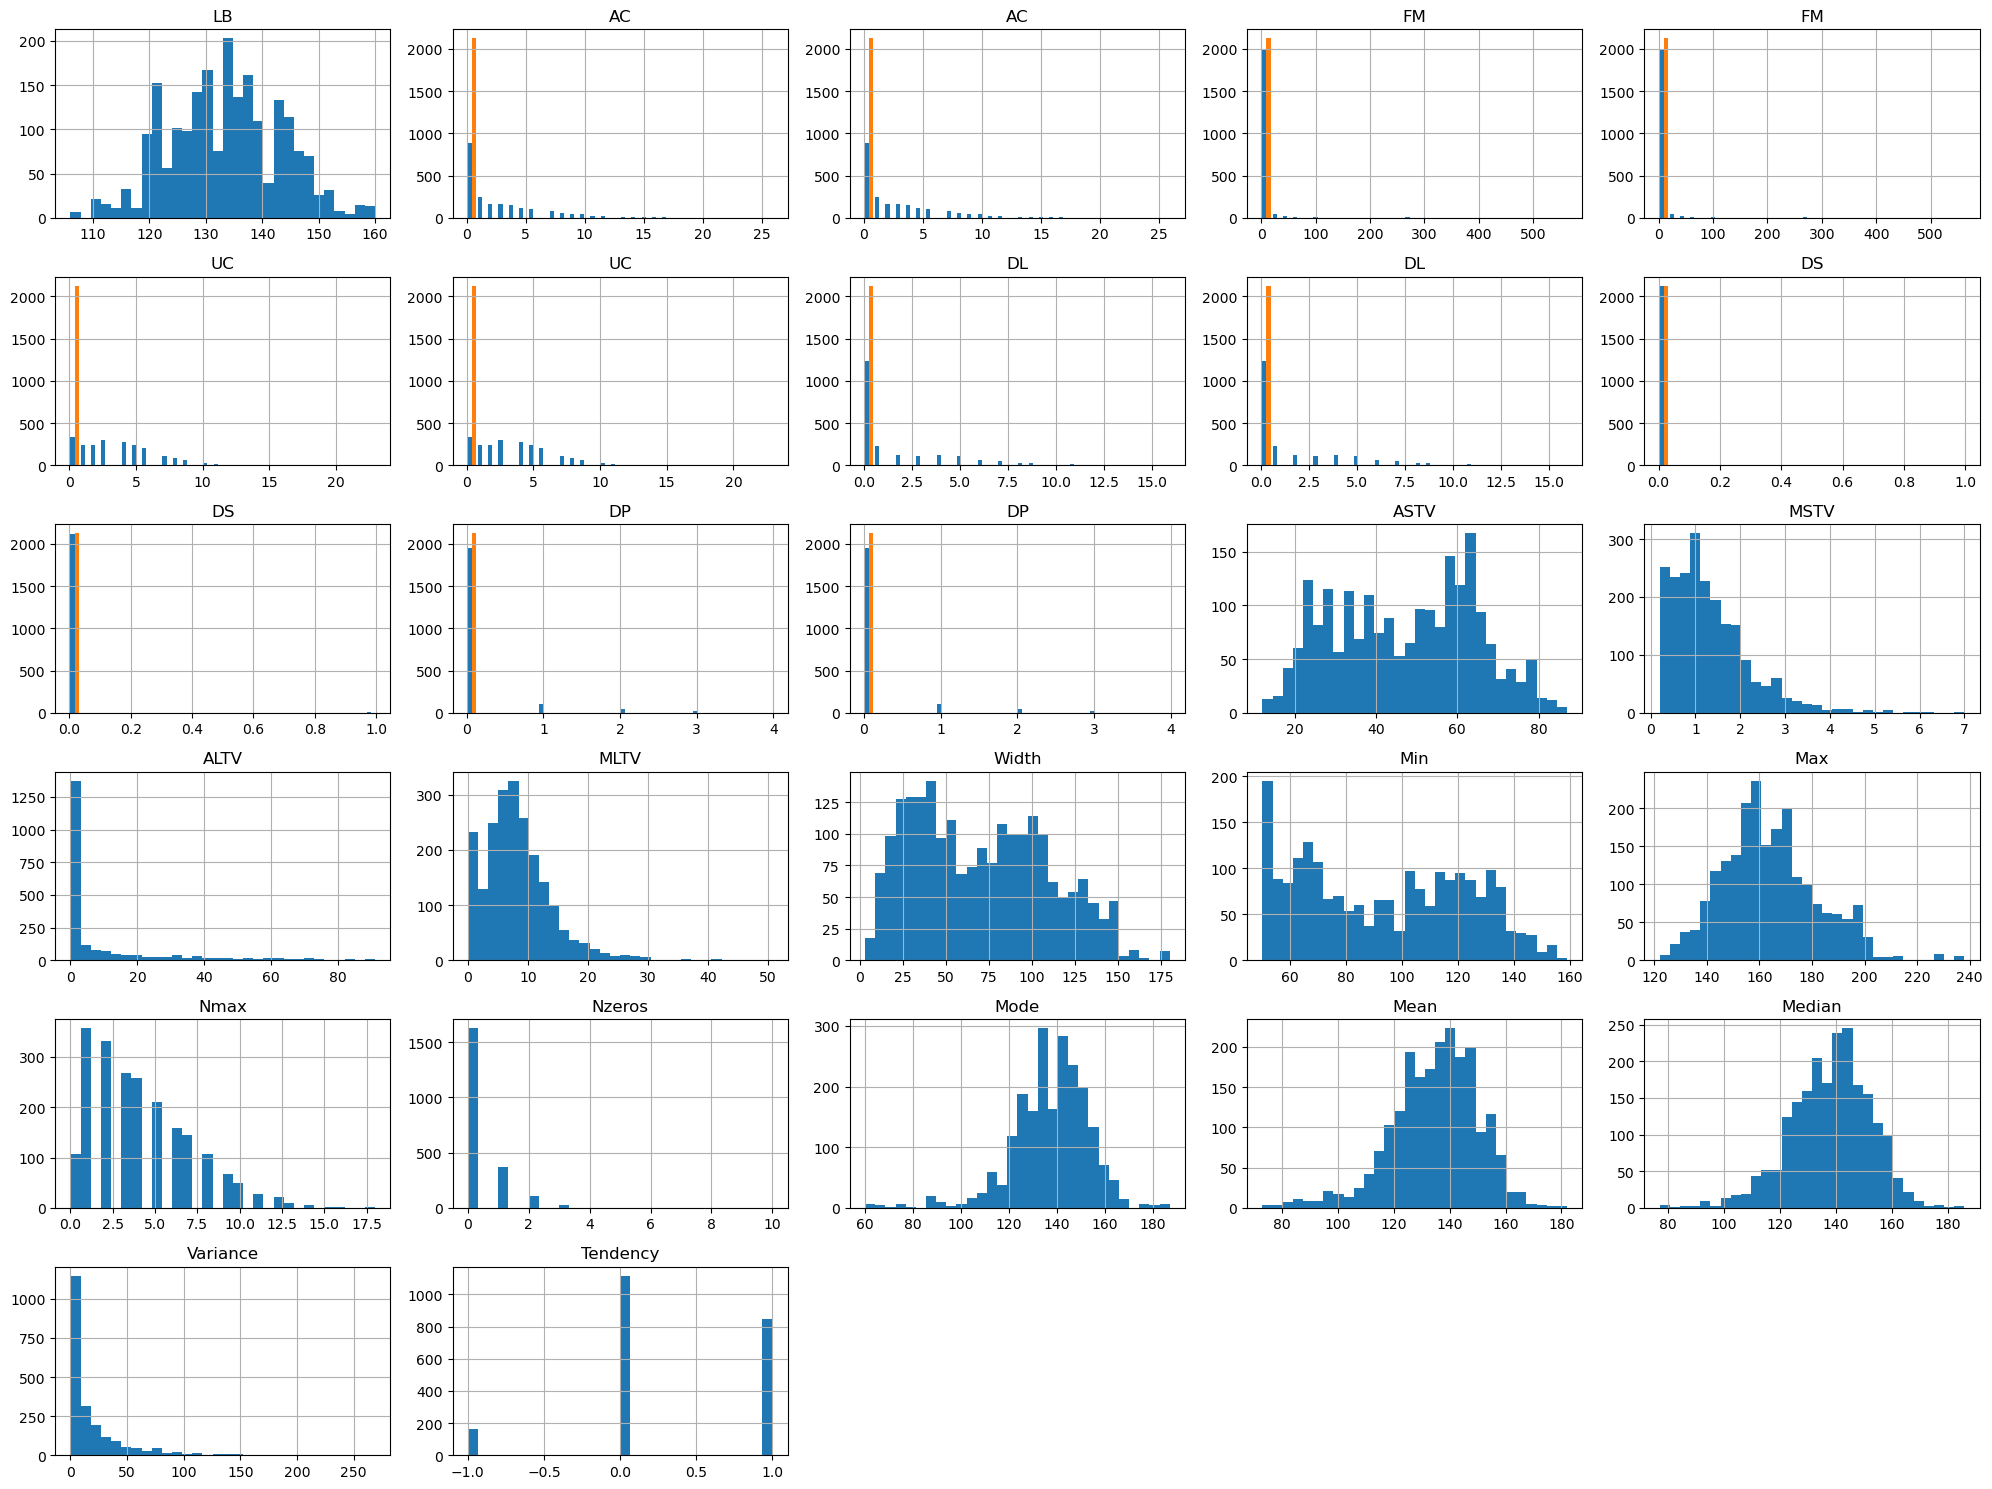

In [ ]:
import matplotlib.pyplot as plt

X_imputed.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

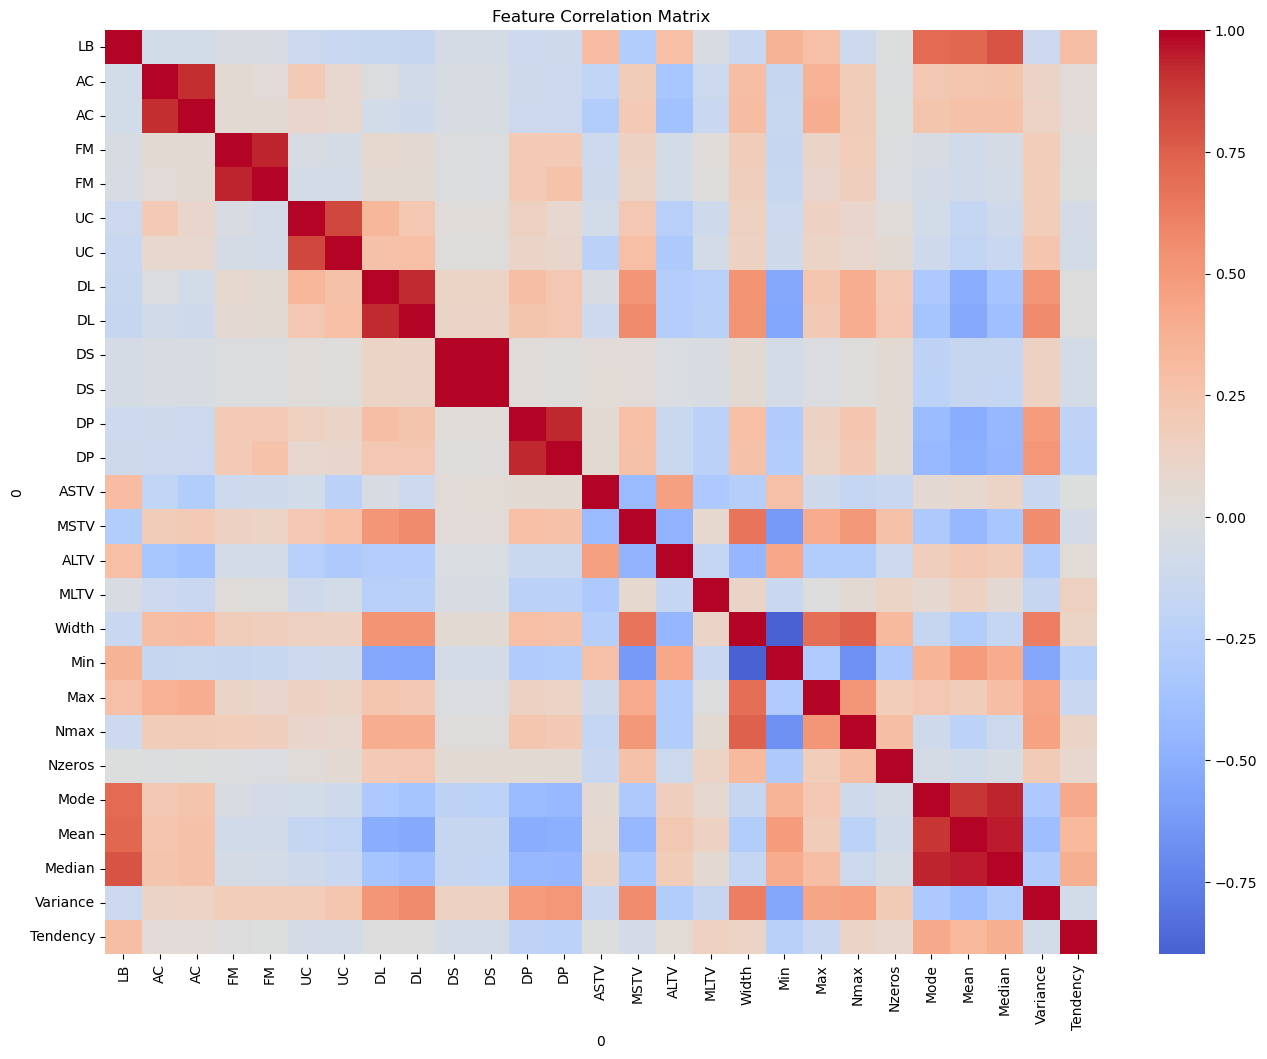

In [12]:
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(X_imputed.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [20]:

import numpy as np
from scipy import stats

feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

def detect_skewness(df, feature_cols):
    """Calculate skewness for all features"""
    
    skew_results = []
    
    for col in feature_cols:
        data = X_imputed[col].values.flatten()
        skew_val = pd.Series(data).skew()  # pandas skewness
        skew_test = stats.skewtest(data)  # statistical test
        
        # Interpret skewness magnitude
        if abs(skew_val) < 0.5:
            interpretation = "Approximately symmetric"
        elif abs(skew_val) < 1:
            interpretation = "Moderately skewed"
        else:
            interpretation = "Highly skewed"
        
        # Direction
        direction = "Right-skewed (positive)" if skew_val > 0 else "Left-skewed (negative)"
        
        skew_results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Direction': direction,
            'Interpretation': interpretation,
            'P-value': skew_test.pvalue,
            'Significant': skew_test.pvalue < 0.05
        })
    
    # Create DataFrame
    skew_df = pd.DataFrame(skew_results)
    skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)
    
    print("=" * 80)
    print("SKEWNESS ANALYSIS FOR CTG DATA")
    print("=" * 80)
    print(skew_df.to_string(index=False))
    
    return skew_df

skewness_df = detect_skewness(X_imputed, feature_cols)


SKEWNESS ANALYSIS FOR CTG DATA
 Feature  Skewness               Direction          Interpretation       P-value  Significant
      DS 24.593795 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      FM 13.359059 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      DP  6.217712 Right-skewed (positive)           Highly skewed  0.000000e+00         True
  Nzeros  3.920287 Right-skewed (positive)           Highly skewed 1.277443e-270         True
Variance  3.219974 Right-skewed (positive)           Highly skewed 3.954336e-227         True
      DL  2.980882 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      AC  2.701460 Right-skewed (positive)           Highly skewed  0.000000e+00         True
    ALTV  2.195075 Right-skewed (positive)           Highly skewed 8.672645e-155         True
    MSTV  1.657339 Right-skewed (positive)           Highly skewed 3.647532e-112         True
      UC  1.584827 Right-skew

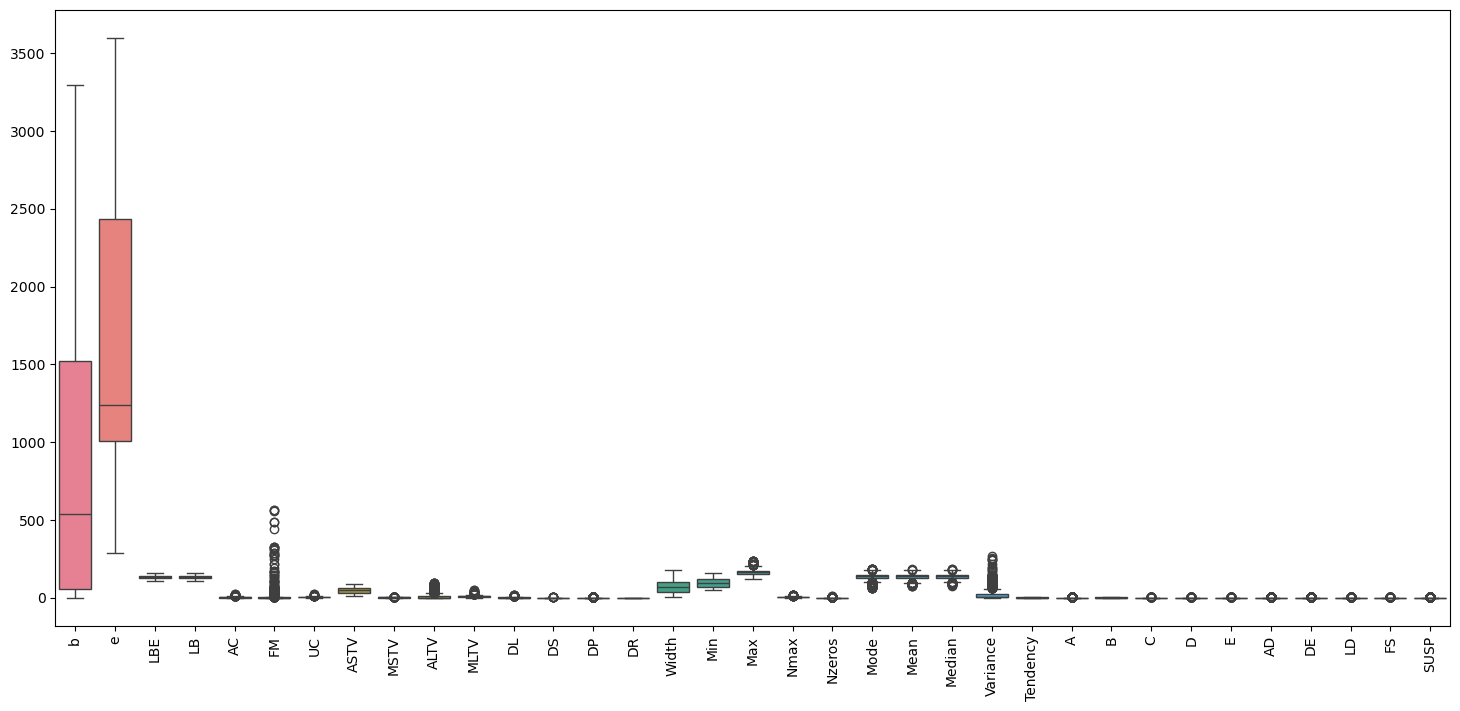

In [ ]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=X_imputed_numeric)
plt.xticks(rotation=90)
plt.show()

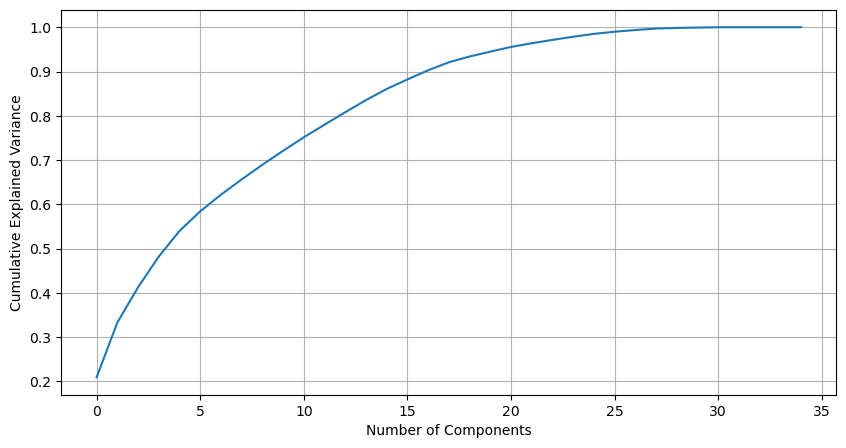

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()